# Clasificador de Videojuegos con CNN



In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
base_dir = 'videogames-cnn-dataset_V3'
train_dir = os.path.join(base_dir,'train')
val_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
							rescale = 1./255,
							rotation_range = 10,
							width_shift_range = 0.2,
						#	height_shift_range = 0.2,
						#	shear_range = 0.3,
							zoom_range = 0.3,
							horizontal_flip = True)

Found 27913 images belonging to 6 classes.
Found 3487 images belonging to 6 classes.


<Figure size 640x480 with 0 Axes>

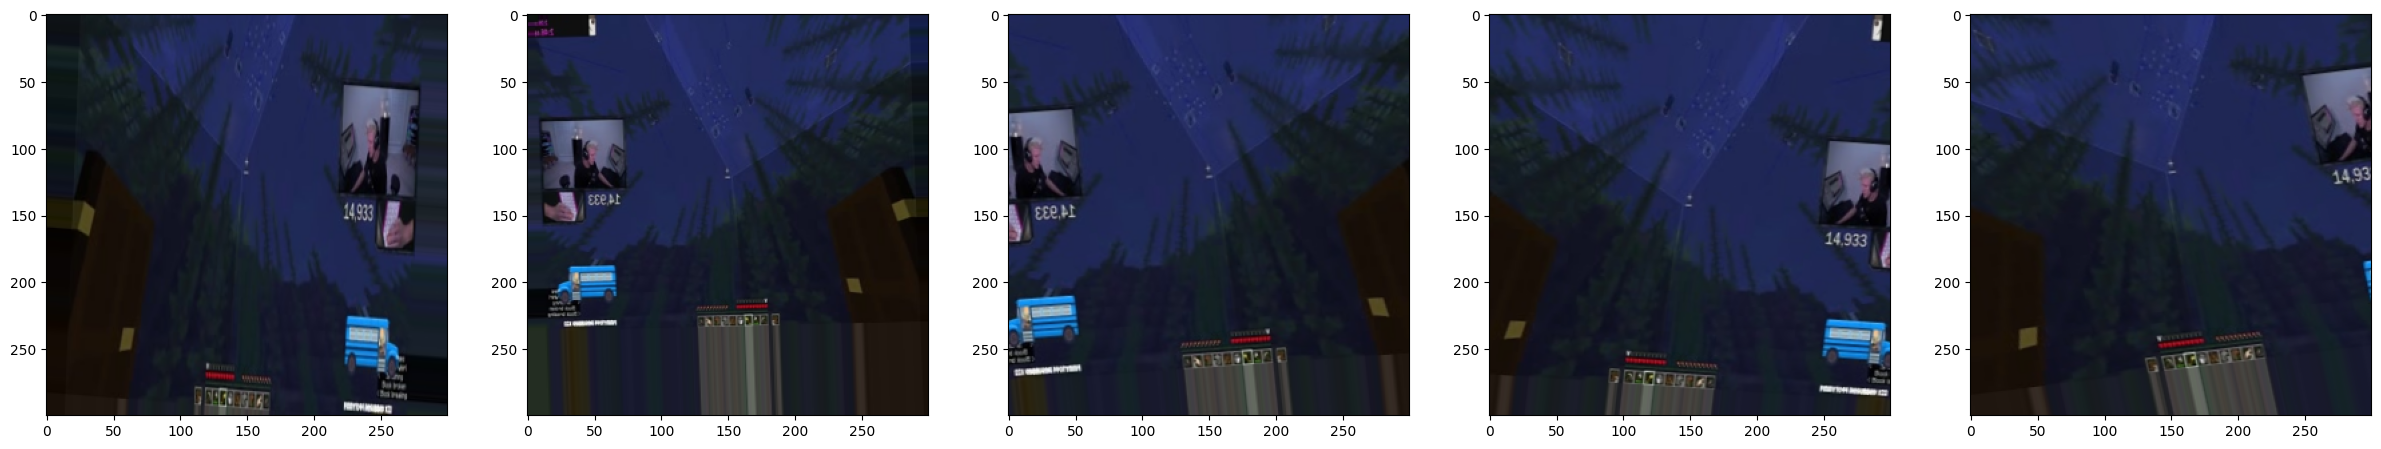

In [3]:
train_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (300, 300),
							batch_size = 128,
							class_mode ='categorical',
							)

val_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(300, 300),
    batch_size=128,
    class_mode='categorical'
)


plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 5, figsize=(30, 8))

for i in range(5) :
  axarr[i].imshow(train_generator[0][0][0])

Found 27913 images belonging to 6 classes.
(128, 300, 300, 3)
[[0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 

<Figure size 640x480 with 0 Axes>

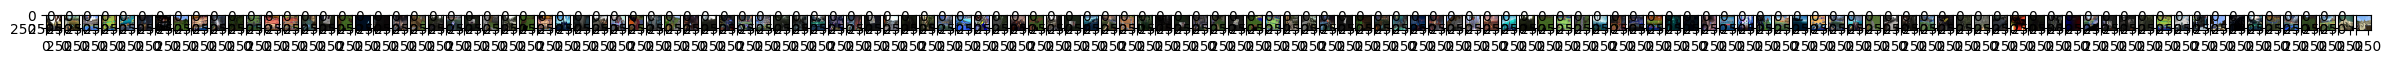

In [4]:
train_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (300, 300),
							batch_size = 128,
							class_mode ='categorical',
							)


images , labels = train_generator[0]

print(images.shape)
print(labels)


plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

In [5]:
#path = "videogames-cnn-dataset"

train_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (300, 300),
							batch_size = 128,
							class_mode ='categorical',
							# save_to_dir= path + '/augmented',
							# save_prefix='aug',
							# save_format='png'
							)

Found 27913 images belonging to 6 classes.


In [6]:
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

# 1. Activamos mixed precision para aprovechar los Tensor Cores de tu RTX 3060
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

model = models.Sequential()

# Capas intermedias (usarán float16 automáticamente)
model.add(layers.Conv2D(10, (3, 3), activation="relu", input_shape=(300, 300, 3)))
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))

# 2. Capa de salida: Es fundamental que sea float32 para evitar errores de precisión
# Nota: Usas sigmoid y binary_crossentropy para 3 clases; 
# esto sugiere que es un problema multi-etiqueta.
model.add(layers.Dense(6, activation='softmax', dtype='float32'))

model.summary()

model.compile(loss='categorical_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=2e-5),
						metrics=['accuracy'])


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060, compute capability 8.6
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 298, 298, 10)      280       
                                                                 
 flatten (Flatten)           (None, 888040)            0         
                                                                 
 dense (Dense)               (None, 256)               227338496 
                                                                 
 dense_1 (Dense)             (None, 6)                 1542      
                                                                 
Total params: 227,340,318
Trainable params: 227,340,318
Non-trainable params: 0

In [7]:
import tensorflow as tf

print(tf.__version__)

# Listar las GPUs disponibles
gpus = tf.config.list_physical_devices('GPU')
print("GPUs disponibles:", len(gpus))

if gpus:
    for gpu in gpus:
        print(f"Nombre del dispositivo: {gpu}")
else:
    print("No se detectó ninguna GPU. Se usará la CPU.")

2.10.0
GPUs disponibles: 1
Nombre del dispositivo: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [8]:
import tensorflow as tf

# Esto debe devolver una lista con tu GPU
print("Dispositivos detectados:", tf.config.list_physical_devices())

# Esto confirma que TF puede usar la GPU para cálculos
print("¿TensorFlow puede usar la GPU?:", tf.test.is_built_with_cuda())


Dispositivos detectados: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
¿TensorFlow puede usar la GPU?: True


In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
# Create Tensorflow checkpoint object with epoch and batch details
checkpoint_path = "./checkpoints_Base/checkpoint.weights.h5"
checkpoint_50 = ModelCheckpoint(filepath = checkpoint_path,
                                  save_weights_only = False,
                                  save_freq = "epoch",
                                  monitor = "val_accuracy",
                                  save_best_only = True,
                                  verbose = 1)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',          # observa la pérdida de validación
    patience=2,
    restore_best_weights=True,
    verbose=1
)

In [12]:

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,                  # máximo que se entrenó
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
219/219 [==============================] - 651s 3s/step - loss: 2.5217 - accuracy: 0.4307 - val_loss: 1.1849 - val_accuracy: 0.6544
Epoch 2/10
219/219 [==============================] - 645s 3s/step - loss: 1.5905 - accuracy: 0.5494 - val_loss: 0.8639 - val_accuracy: 0.7072
Epoch 3/10
219/219 [==============================] - 653s 3s/step - loss: 1.2926 - accuracy: 0.6195 - val_loss: 1.0480 - val_accuracy: 0.6797
Epoch 4/10
219/219 [==============================] - 583s 3s/step - loss: 1.0926 - accuracy: 0.6766 - val_loss: 0.7464 - val_accuracy: 0.7623
Epoch 5/10
219/219 [==============================] - 558s 3s/step - loss: 0.9104 - accuracy: 0.7253 - val_loss: 0.5806 - val_accuracy: 0.8182
Epoch 6/10
219/219 [==============================] - 579s 3s/step - loss: 0.7871 - accuracy: 0.7616 - val_loss: 0.7097 - val_accuracy: 0.7691
Epoch 7/10
219/219 [==============================] - 635s 3s/step - loss: 0.6812 - accuracy: 0.7914 - val_loss: 0.4459 - val_accuracy: 0.8483

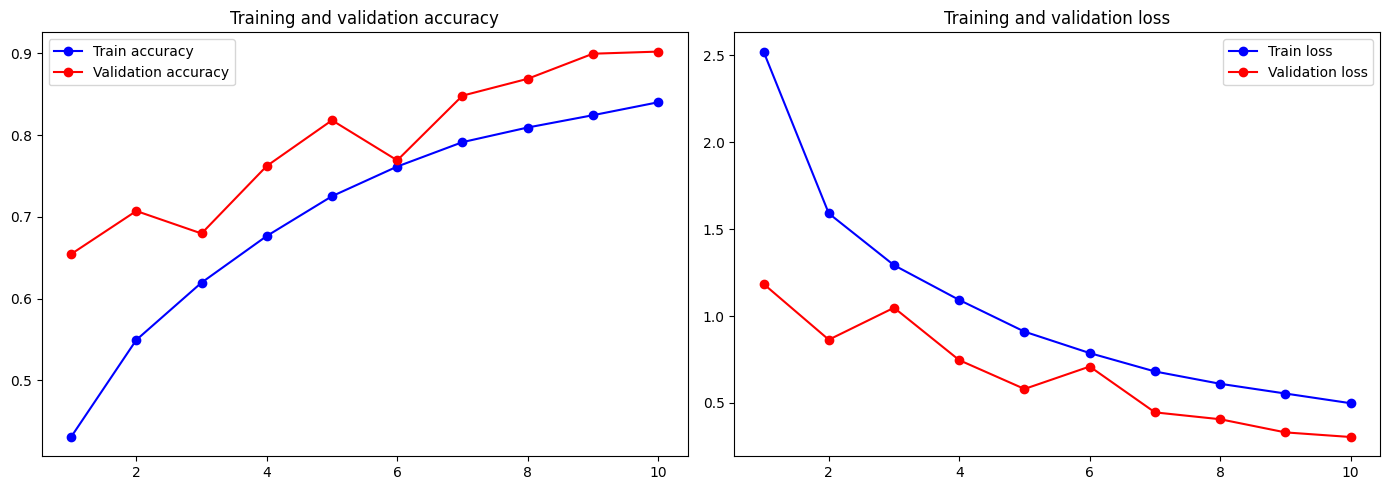

In [13]:
import matplotlib.pyplot as plt

def plot_history(hist):
    acc = hist.history['accuracy']
    val_acc = hist.history.get('val_accuracy', [])
    loss = hist.history['loss']
    val_loss = hist.history.get('val_loss', [])
    
    epochs_range = range(1, len(acc)+1)
    
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))
    
    ax1.plot(epochs_range, acc, 'bo-', label='Train accuracy')
    if val_acc:
        ax1.plot(epochs_range, val_acc, 'ro-', label='Validation accuracy')
    ax1.set_title('Training and validation accuracy')
    ax1.legend()
    
    ax2.plot(epochs_range, loss, 'bo-', label='Train loss')
    if val_loss:
        ax2.plot(epochs_range, val_loss, 'ro-', label='Validation loss')
    ax2.set_title('Training and validation loss')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)